<a href="https://colab.research.google.com/github/daniivelascoo/ifp-programacion-ia/blob/main/Teoria_2_1_C_Metricas_Confusion_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Teoría Bloque C: La Verdadera Evaluación
**Sprint 2.1 - Metodología del Machine Learning**

La pregunta más importante no es "¿Cómo entrenar?", sino "¿Cómo saber si mi modelo es bueno?".

### 🎯 Objetivos:
1.  **Accuracy:** Entender por qué es una métrica engañosa.
2.  **Matriz de Confusión:** La herramienta para desglosar aciertos y errores.
3.  **Falsos Positivos vs Falsos Negativos:** Entender el impacto en el negocio (el dilema médico).

## 1. Accuracy: La Métrica Engañosa

El **Accuracy** es el porcentaje de aciertos totales.
> $Accuracy = \frac{Aciertos}{Total\ de\ Predicciones}$

Es fácil de entender, pero falla cuando los datos están **desbalanceados** (ej. el 99% de los correos son legítimos y solo el 1% es SPAM).

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# SIMULACIÓN DE DATOS DESBALANCEADOS (Detección de Fraude)
# Realidad: 95% Sano (0), 5% Enfermo (1)
y_real = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1]) # 9 sanos, 1 enfermo

# MODELO INÚTIL: Predice siempre 'Sano' (0)
y_predicho_inutil = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Calcula la Precisión:
acc = accuracy_score(y_real, y_predicho_inutil)

print("--- Evaluación de Modelo Inútil ---")
print(f"Predicción (Train): {y_predicho_inutil}")
print(f"Precisión (Accuracy): {acc:.1%}")

# PREGUNTA: ¿Es un buen modelo?
# R: No. Ha fallado en el único caso importante (el fraude), pero su accuracy es del 90%. ¡Engañoso!

--- Evaluación de Modelo Inútil ---
Predicción (Train): [0 0 0 0 0 0 0 0 0 0]
Precisión (Accuracy): 90.0%


## 2. La Matriz de Confusión (El Desglose Profesional)

Para saber cómo se equivoca realmente el modelo, usamos la Matriz de Confusión.
Es una tabla 2x2 que separa los 4 resultados posibles:

<br>

| | **PREDICHO SANO (0)** | **PREDICHO ENFERMO (1)** |
| :--- | :--- | :--- |
| **REAL SANO (0)** | **Verdadero Negativo (VN)** | **Falso Positivo (FP)** |
| **REAL ENFERMO (1)** | **Falso Negativo (FN)** | **Verdadero Positivo (VP)** |

<br>

*   **VP:** Acierto. Dijiste 1, era 1.
*   **FN (¡Peligroso!):** Fallo. Dijiste 0 (Sano), pero era 1 (Enfermo).
*   **FP:** Fallo. Dijiste 1 (Enfermo), pero era 0 (Sano).

--- Matriz de Confusión (90% Acc) ---
[[9 0]
 [1 0]]


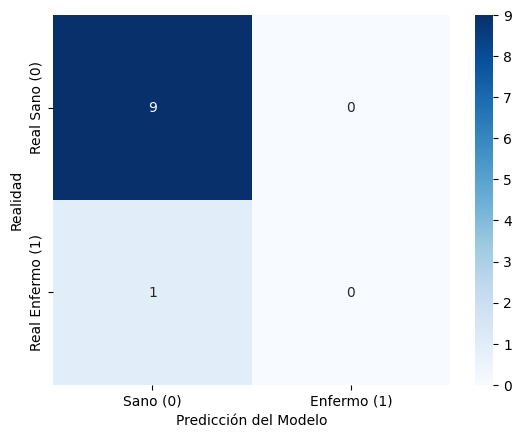

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Usamos el mismo ejemplo del Fraude de arriba
# y_real =      [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
# y_predicho =  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

matriz = confusion_matrix(y_real, y_predicho_inutil)

print("--- Matriz de Confusión (90% Acc) ---")
print(matriz)

# Para verlo mejor, usamos un Heatmap
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (0)', 'Enfermo (1)'],
            yticklabels=['Real Sano (0)', 'Real Enfermo (1)'])
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

# PREGUNTA VISUAL:
# ¿Dónde está el error grave (Falso Negativo) en la Matriz?
# En la celda inferior izquierda: La IA falló al clasificar al único caso '1'.

## 3. El Dilema: Precision y Recall

Estas dos métricas se calculan a partir de la Matriz de Confusión y resuelven el problema del Accuracy.

*   **Precision (Precisión):** De todas las veces que la IA predijo POSITIVO, ¿cuántas acertó?
    > **Foco:** Minimizar **Falsos Positivos (FP)**. (No asustar a la gente sana).
    > *Uso:* Filtro de SPAM (No queremos que un correo importante acabe en la carpeta de SPAM).

*   **Recall (Sensibilidad o Recuperación):** De todos los casos POSITIVOS que existían, ¿cuántos fue capaz de detectar?
    > **Foco:** Minimizar **Falsos Negativos (FN)**. (No dejar a nadie enfermo sin diagnosticar).
    > *Uso:* Detección de Fraude/Enfermedades (¡Es vital encontrar todos los casos!).

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# DATOS DE EJEMPLO: DETECCIÓN DE VIRUS
# 0 = Sano
# 1 = Con Virus
y_real =     [1, 1, 1, 0, 0, 0, 1, 0] # 4 personas con virus, 4 sanas
y_predicho = [1, 0, 1, 0, 0, 1, 1, 0] # El modelo se equivoca un poco

# 1. DESGLOSE DE LA MATRIZ
matriz = confusion_matrix(y_real, y_predicho)
# Extraemos los 4 valores mágicos
# TN: True Negative, FP: False Positive, FN: False Negative, TP: True Positive
tn, fp, fn, tp = matriz.ravel()

print(f"Verdaderos Positivos (Aciertos Virus): {tp}")
print(f"Falsos Negativos (Virus no detectados - PELIGRO): {fn}")
print(f"Falsos Positivos (Falsa alarma): {fp}")
print("-" * 30)

# 2. CÁLCULO MANUAL (Para entender la lógica)

# PRECISION: Calidad de la predicción positiva
# "Cuando el modelo gritó ¡VIRUS!, ¿cuántas veces tenía razón?"
precision_manual = tp / (tp + fp)
print(f"🔎 PRECISION (Calidad): {precision_manual:.2f}")
print(f"   Explicación: De los {tp+fp} casos que el modelo marcó como Virus, el {precision_manual:.0%} eran reales.")

# RECALL: Cantidad de realidad capturada
# "De todos los virus que había en el mundo, ¿cuántos encontró?"
recall_manual = tp / (tp + fn)
print(f"🎣 RECALL (Sensibilidad): {recall_manual:.2f}")
print(f"   Explicación: De los {tp+fn} virus reales que había, el modelo detectó el {recall_manual:.0%}.")

# F1-SCORE: El equilibrio
# Es una media armónica entre Precision y Recall.
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
print(f"⚖️ F1-SCORE (Equilibrio): {f1_manual:.2f}")

print("-" * 30)
print("3. REPORTE AUTOMÁTICO (Resumen)")
# Ahora que entendemos las mates, vemos el reporte completo
# target_names ayuda a leerlo mejor
print(classification_report(y_real, y_predicho, target_names=['Sano (0)', 'Virus (1)']))

Verdaderos Positivos (Aciertos Virus): 3
Falsos Negativos (Virus no detectados - PELIGRO): 1
Falsos Positivos (Falsa alarma): 1
------------------------------
🔎 PRECISION (Calidad): 0.75
   Explicación: De los 4 casos que el modelo marcó como Virus, el 75% eran reales.
🎣 RECALL (Sensibilidad): 0.75
   Explicación: De los 4 virus reales que había, el modelo detectó el 75%.
⚖️ F1-SCORE (Equilibrio): 0.75
------------------------------
3. REPORTE AUTOMÁTICO (Resumen)
              precision    recall  f1-score   support

    Sano (0)       0.75      0.75      0.75         4
   Virus (1)       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8

